# Unsupervised Learning: Clustering Techniques

## What is Clustering?

**Clustering** is like sorting a mixed box of fruits into groups - apples with apples, oranges with oranges - but the computer does it automatically without being told what an "apple" or "orange" is!

In machine learning terms:
- **Unsupervised Learning**: We don't tell the algorithm what groups exist
- **Clustering**: The algorithm finds natural groups in the data by itself
- **Applications**: Customer segmentation, grouping similar products, finding patterns

**Real-World Example:**
Imagine a bank wants to group customers. Without labels, clustering can discover:
- Group 1: Young customers with small loans
- Group 2: Middle-aged with medium loans  
- Group 3: Older customers with large loans

**In This Notebook:**
We'll use the German Credit dataset to discover customer segments using:
1. **K-Means Clustering** - Fast, requires you to specify number of groups
2. **Hierarchical Clustering** - Slower, shows relationships between groups

## 📦 Step 1: Install Required Libraries

Before we start, we need to install Python libraries (like installing apps on your phone).

**What each library does:**
- `numpy` - For mathematical calculations
- `pandas` - For working with data tables (like Excel)
- `matplotlib` - For creating charts and graphs
- `seaborn` - For making prettier charts
- `scikit-learn` - Contains all the clustering algorithms
- `scipy` - For hierarchical clustering calculations

**Installation Command:**
```python
pip install numpy pandas matplotlib seaborn scikit-learn scipy
```

Run the cell below ONLY if you haven't installed these libraries yet.

In [1]:
# Uncomment the line below (remove #) if you need to install libraries
!pip install numpy pandas matplotlib seaborn scikit-learn scipy

print("✓ If you see this message, libraries are ready!")
print("✓ If you get an error, uncomment the line above and run again")

Defaulting to user installation because normal site-packages is not writeable
✓ If you see this message, libraries are ready!
✓ If you get an error, uncomment the line above and run again


## Step 2: Import Libraries

Now we'll import (load) the libraries we need. Think of this like opening the apps we installed.

**What each import does:**
- `warnings` - To hide warning messages and keep output clean
- `numpy as np` - For number crunching (we call it 'np' for short)
- `pandas as pd` - For data tables (we call it 'pd')
- `matplotlib.pyplot as plt` - For plotting graphs (we call it 'plt')
- `seaborn as sns` - For beautiful statistical plots (we call it 'sns')

In [2]:
# Import basic libraries
import warnings
warnings.filterwarnings('ignore')  # Hide warning messages

import numpy as np      # For numerical operations
import pandas as pd     # For data manipulation

import matplotlib.pyplot as plt  # For plotting
import seaborn as sns            # For statistical visualizations

print("✓ Basic libraries loaded successfully!")

✓ Basic libraries loaded successfully!


### Import Clustering Algorithms and Tools

Now we'll import the specific tools for clustering:

**Clustering Algorithms:**
- `KMeans` - The K-Means clustering algorithm
- `AgglomerativeClustering` - The Hierarchical clustering algorithm

**Preprocessing Tools:**
- `StandardScaler` - To scale/normalize our data (make all numbers comparable)
- `LabelEncoder` - To convert text categories (like 'male'/'female') into numbers

**Other Tools:**
- `PCA` - To reduce dimensions for visualization (we can't plot 9D data, so we reduce to 2D)
- `silhouette_score`, `davies_bouldin_score`, `calinski_harabasz_score` - To measure clustering quality
- `dendrogram`, `linkage` - To create the tree diagram for hierarchical clustering

In [3]:
# Import clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering

# Import preprocessing tools
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Import dimensionality reduction
from sklearn.decomposition import PCA

# Import evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Import hierarchical clustering tools
from scipy.cluster.hierarchy import dendrogram, linkage

# Set pandas display options (show all columns)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')  # Use a nice color palette

print("✓ All clustering tools loaded!")
print("✓ Ready to start clustering!")

✓ All clustering tools loaded!
✓ Ready to start clustering!


## Step 3: Load the Dataset

We'll use the **German Credit Risk Dataset** which contains information about 1000 bank customers.

**About the Dataset:**
- **Original Purpose**: Predict if a customer will default on a loan (supervised learning)
- **Our Purpose**: Ignore the labels and discover natural customer groups (unsupervised learning)
- **Features**: Age, credit amount, loan duration, gender, housing, purpose, etc.
- **Why This Works**: Even though it has labels, we can pretend we don't know them and let clustering discover patterns

**What the code below does:**
1. Downloads the dataset from GitHub
2. Loads it into a pandas DataFrame (like an Excel table)
3. Creates a copy to work with (keeps original safe)
4. Prints basic information about the dataset

In [4]:
# Load data from online source
url = "https://raw.githubusercontent.com/ek-chris/Practice_datasets/refs/heads/main/German_Credit.csv"
credit = pd.read_csv(url)  # pd.read_csv() reads CSV files

# Create a working copy (keeps original data safe)
data = credit.copy()

# Print dataset information
print("✓ Dataset loaded successfully!")
print(f"\nDataset Shape: {data.shape}")
print(f"  → {data.shape[0]} rows (customers)")
print(f"  → {data.shape[1]} columns (features)")

✓ Dataset loaded successfully!

Dataset Shape: (1000, 10)
  → 1000 rows (customers)
  → 10 columns (features)


### Explore the Dataset

Let's look at the data to understand what we're working with.

**What `data.head(10)` does:**
- Shows the first 10 rows of our dataset
- Each row = one customer
- Each column = one feature (Age, Credit amount, etc.)

In [5]:
# Display first 10 rows
data.head(10)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,67,male,skilled,own,little,little,1169,6,0,radio/TV
1,22,female,skilled,own,little,moderate,5951,48,1,radio/TV
2,49,male,unskilled_and_non-resident,own,little,little,2096,12,0,education
3,45,male,skilled,free,little,little,7882,42,0,furniture/equipment
4,53,male,skilled,free,little,little,4870,24,1,car
5,35,male,unskilled_and_non-resident,free,little,moderate,9055,36,0,education
6,53,male,skilled,own,quite rich,moderate,2835,24,0,furniture/equipment
7,35,male,highly skilled,rent,little,moderate,6948,36,0,car
8,61,male,unskilled_and_non-resident,own,rich,moderate,3059,12,0,radio/TV
9,28,male,highly skilled,own,little,moderate,5234,30,1,car


### Dataset Information

Let's see what types of data we have and if there are any missing values.

**What `data.info()` shows:**
- Column names
- Data types (int64 = whole numbers, object = text)
- Non-null count (how many values are NOT missing)
- Memory usage

In [6]:
# Get detailed dataset information
print("Dataset Information:")
print("=" * 60)
data.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   str  
 3   Housing           1000 non-null   str  
 4   Saving accounts   1000 non-null   str  
 5   Checking account  1000 non-null   str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Risk              1000 non-null   int64
 9   Purpose           1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 119.2 KB


### Statistical Summary

Let's see the statistics (mean, min, max, etc.) for numerical columns.

**What `data.describe()` shows:**
- `count`: How many values
- `mean`: Average value
- `std`: Standard deviation (how spread out)
- `min`: Smallest value
- `25%`, `50%`, `75%`: Quartiles
- `max`: Largest value

In [7]:
# Get statistical summary
data.describe()

,Age,Credit amount,Duration,Risk
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,3271.258000,20.903000,0.300000
std,11.375469,2822.736876,12.058814,0.458487
min,19.000000,250.000000,4.000000,0.000000
25%,27.000000,1365.500000,12.000000,0.000000
50%,33.000000,2319.500000,18.000000,0.000000
75%,42.000000,3972.250000,24.000000,1.000000
max,75.000000,18424.000000,72.000000,1.000000


## Step 4: Check for Missing Values

Missing values are like blank cells in Excel - we need to find and handle them.

**Why check for missing values?**
- Clustering algorithms can't work with missing data
- We need to fill or remove missing values

**What the code below does:**
1. Count missing values in each column using `isnull().sum()`
2. Calculate percentage of missing values
3. Create a table showing columns with missing data
4. Plot a bar chart if any missing values found

In [8]:
# Count missing values
missing_data = data.isnull().sum()  # Count NaN (Not a Number) values
missing_percent = (missing_data / len(data)) * 100  # Convert to percentage

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage': missing_percent
})

print("Missing Values Summary:")
print("=" * 60)
# Show only columns with missing values
print(missing_df[missing_df['Missing Values'] > 0])

# Plot missing values if any exist
if missing_df['Missing Values'].sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_df[missing_df['Missing Values'] > 0]['Percentage'].plot(kind='bar', color='coral')
    plt.title('Percentage of Missing Values by Feature', fontsize=14, fontweight='bold')
    plt.xlabel('Features')
    plt.ylabel('Percentage Missing (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ Great! No missing values found!")

Missing Values Summary:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []

✓ Great! No missing values found!


## Step 5: Exploratory Data Analysis (EDA)

Before clustering, let's understand our data through visualization.

### Risk Distribution

**What is 'Risk'?**
- 0 = Good credit (customer repaid loan)
- 1 = Bad credit (customer defaulted)

**Why visualize this?**
- After clustering, we can see which clusters have more risky customers
- Helps validate if our clusters make business sense

**What the code does:**
1. Count how many customers in each risk category
2. Create a bar chart showing the distribution
3. Print percentages for interpretation

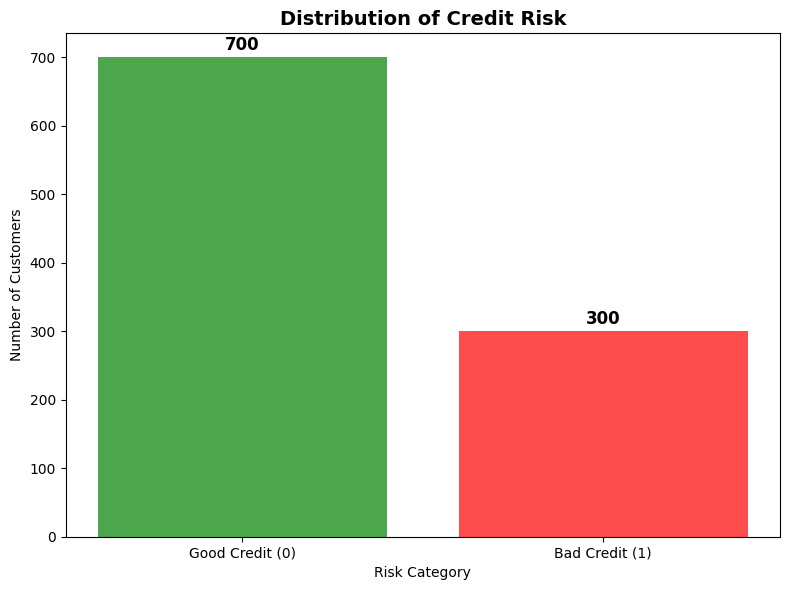

Good Credit (0): 700 customers (70.00%)
Bad Credit (1): 300 customers (30.00%)

Interpretation: 70.0% of customers have good credit history


In [9]:
# Count customers in each risk category
risk_counts = data['Risk'].value_counts()  # Count 0s and 1s

# Create bar chart
plt.figure(figsize=(8, 6))
plt.bar(['Good Credit (0)', 'Bad Credit (1)'], 
        risk_counts.values, 
        color=['green', 'red'], 
        alpha=0.7)
plt.title('Distribution of Credit Risk', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.xlabel('Risk Category')

# Add count labels on top of bars
for i, v in enumerate(risk_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary
print(f"Good Credit (0): {risk_counts[0]} customers ({risk_counts[0]/len(data)*100:.2f}%)")
print(f"Bad Credit (1): {risk_counts[1]} customers ({risk_counts[1]/len(data)*100:.2f}%)")
print(f"\nInterpretation: {risk_counts[0]/len(data)*100:.1f}% of customers have good credit history")

### Numerical Features Distribution

Let's visualize the distribution of key numerical features.

**Why these three features?**
- **Age**: Customer demographics
- **Credit amount**: Loan size
- **Duration**: Loan length in months

**What histograms show:**
- The shape of data distribution (normal, skewed, etc.)
- Most common values (peaks)
- Outliers (unusual values)

**What the code does:**
1. Creates 3 side-by-side histograms
2. Each histogram shows frequency of values
3. `bins=30` means divide data into 30 groups

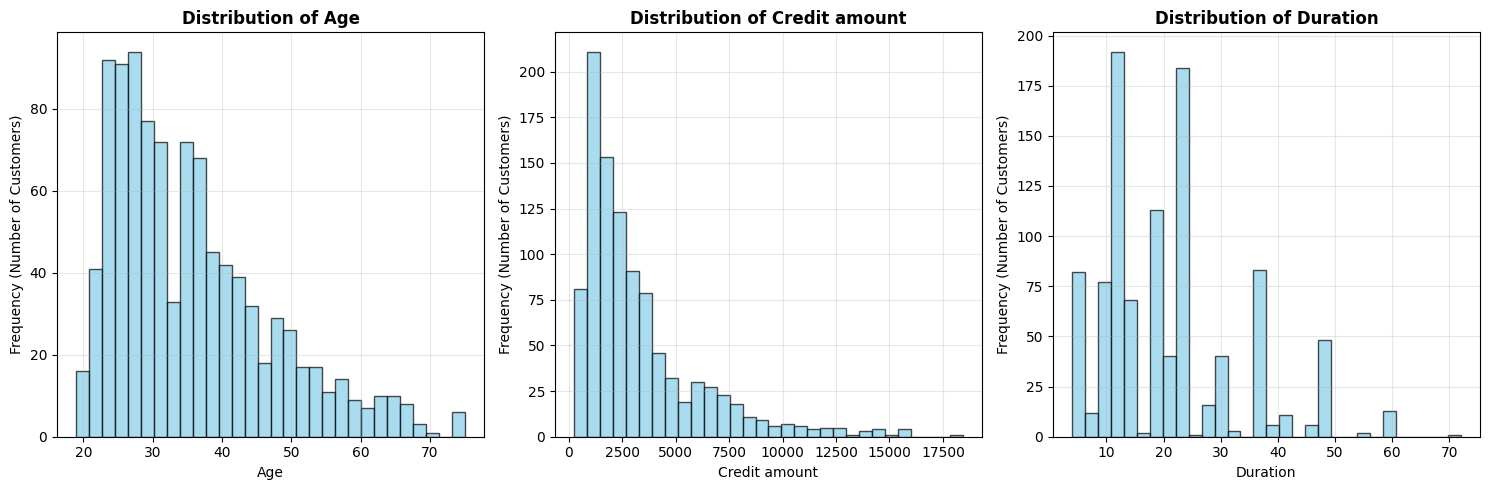

💡 What to look for:
  • Age: Is it normally distributed? Any concentration?
  • Credit amount: Are most loans small or large?
  • Duration: Do customers prefer short or long-term loans?


In [10]:
# Select numerical features to visualize
numerical_cols = ['Age', 'Credit amount', 'Duration']

# Create 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot histogram for each feature
for idx, col in enumerate(numerical_cols):
    axes[idx].hist(data[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency (Number of Customers)', fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print insights
print("💡 What to look for:")
print("  • Age: Is it normally distributed? Any concentration?")
print("  • Credit amount: Are most loans small or large?")
print("  • Duration: Do customers prefer short or long-term loans?")

### Categorical Features Distribution

Now let's look at categorical (text) features.

**Features:**
- **Sex**: Gender distribution
- **Housing**: Do customers own, rent, or have free housing?
- **Purpose**: Why do customers need credit?

**What bar charts show:**
- Count of customers in each category
- Most common categories

**What the code does:**
1. `value_counts()` counts how many customers in each category
2. `.plot(kind='bar')` creates bar charts
3. Shows 3 charts side by side for comparison

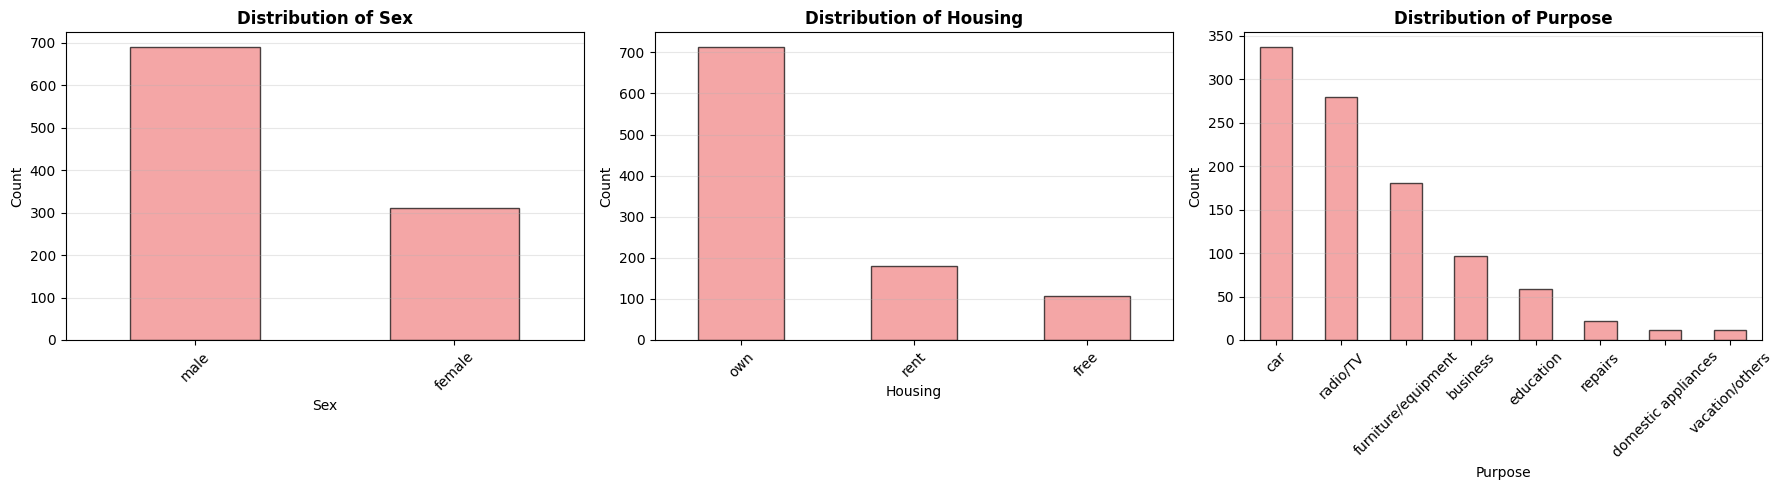

💡 Observations to note:
  • Gender: Are customers mostly male or female?
  • Housing: Most customers own or rent?
  • Purpose: What's the most common loan purpose?


In [11]:
# Select categorical features
categorical_cols = ['Sex', 'Housing', 'Purpose']

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot bar chart for each feature
for idx, col in enumerate(categorical_cols):
    data[col].value_counts().plot(kind='bar', 
                                    ax=axes[idx], 
                                    color='lightcoral', 
                                    edgecolor='black',
                                    alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("💡 Observations to note:")
print("  • Gender: Are customers mostly male or female?")
print("  • Housing: Most customers own or rent?")
print("  • Purpose: What's the most common loan purpose?")

## Step 6: Data Preprocessing

**What is preprocessing?**
Preprocessing prepares raw data for clustering. Like washing vegetables before cooking!

**Why do we need it?**
1. **Missing values** - Algorithms can't handle blanks
2. **Text data** - Algorithms need numbers, not words
3. **Different scales** - Age (20-70) vs Credit (250-18000) need to be comparable
4. **Feature selection** - Choose relevant columns

**What we'll do:**
1. Fill missing values
2. Convert text to numbers (encoding)
3. Scale all features to same range
4. Select features for clustering

### 6.1 Handle Missing Values

**What the code does:**
1. Creates a copy of data (keep original safe)
2. Finds columns with missing values
3. Fills missing values with the most common value (mode)
4. `.mode()[0]` gets the most frequent value
5. `.fillna()` replaces missing values
6. `inplace=True` modifies the dataframe directly

In [12]:
# Create a working copy
df_cluster = data.copy()

# Fill missing values in 'Saving accounts' column
if df_cluster['Saving accounts'].isnull().sum() > 0:
    most_common_saving = df_cluster['Saving accounts'].mode()[0]  # Find most common value
    df_cluster['Saving accounts'].fillna(most_common_saving, inplace=True)  # Fill missing
    print(f"✓ Filled 'Saving accounts' missing values with: {most_common_saving}")

# Fill missing values in 'Checking account' column
if df_cluster['Checking account'].isnull().sum() > 0:
    most_common_checking = df_cluster['Checking account'].mode()[0]
    df_cluster['Checking account'].fillna(most_common_checking, inplace=True)
    print(f"✓ Filled 'Checking account' missing values with: {most_common_checking}")

# Verify no missing values remain
remaining_missing = df_cluster.isnull().sum().sum()
print(f"\n✓ Missing values handled!")
print(f"  Remaining missing values: {remaining_missing}")


✓ Missing values handled!
  Remaining missing values: 0


### 6.2 Encode Categorical Variables

**Why encode?**
Algorithms understand numbers, not text. We need to convert 'male'/'female' to 0/1.

**What is Label Encoding?**
- Assigns a unique number to each category
- Example: male=0, female=1
- Example: own=0, rent=1, free=2

**What the code does:**
1. Lists all text (categorical) columns
2. For each column, creates a LabelEncoder
3. `.fit_transform()` converts text to numbers
4. Creates new columns with '_encoded' suffix
5. Keeps original columns for reference

In [13]:
# Create a dictionary to store encoders (for later reference)
label_encoders = {}

# List of categorical columns to encode
categorical_features = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

print("Encoding categorical variables:")
print("=" * 60)

# Encode each categorical column
for col in categorical_features:
    le = LabelEncoder()  # Create encoder
    df_cluster[col + '_encoded'] = le.fit_transform(df_cluster[col])  # Encode: text → numbers
    label_encoders[col] = le  # Save encoder for reference
    
    # Show the encoding mapping
    print(f"\n{col}:")
    for i, category in enumerate(le.classes_):
        print(f"  {category} → {i}")

print("\n✓ All categorical variables encoded!")

Encoding categorical variables:

Sex:
  female → 0
  male → 1

Job:
  highly skilled → 0
  skilled → 1
  unskilled_and_non-resident → 2

Housing:
  free → 0
  own → 1
  rent → 2

Saving accounts:
  little → 0
  moderate → 1
  quite rich → 2
  rich → 3

Checking account:
  little → 0
  moderate → 1
  rich → 2

Purpose:
  business → 0
  car → 1
  domestic appliances → 2
  education → 3
  furniture/equipment → 4
  radio/TV → 5
  repairs → 6
  vacation/others → 7

✓ All categorical variables encoded!


### 6.3 Select Features for Clustering

**What features to use?**
We'll use both numerical and encoded categorical features.

**Why these features?**
- **Numerical**: Age, Credit amount, Duration (already numbers)
- **Encoded categorical**: All the '_encoded' columns we just created
- **Exclude**: Risk (that's our validation label, not for clustering)

**What the code does:**
1. Creates a list of feature names
2. Selects only these columns from dataframe
3. `X_cluster` contains our features for clustering

In [14]:
# List of features to use for clustering
clustering_features = [
    # Numerical features
    'Age', 
    'Credit amount', 
    'Duration',
    # Encoded categorical features
    'Sex_encoded', 
    'Job_encoded', 
    'Housing_encoded',
    'Saving accounts_encoded', 
    'Checking account_encoded', 
    'Purpose_encoded'
]

# Select these columns
X_cluster = df_cluster[clustering_features]

print("✓ Features selected for clustering")
print(f"\nShape: {X_cluster.shape}")
print(f"  → {X_cluster.shape[0]} customers")
print(f"  → {X_cluster.shape[1]} features")
print(f"\nFeatures used:")
for i, feat in enumerate(clustering_features, 1):
    print(f"  {i}. {feat}")

✓ Features selected for clustering

Shape: (1000, 9)
  → 1000 customers
  → 9 features

Features used:
  1. Age
  2. Credit amount
  3. Duration
  4. Sex_encoded
  5. Job_encoded
  6. Housing_encoded
  7. Saving accounts_encoded
  8. Checking account_encoded
  9. Purpose_encoded


### 6.4 Scale Features (VERY IMPORTANT!)

**Why scale?**
Different features have different ranges:
- Age: 19-75 (range ~50)
- Credit amount: 250-18,424 (range ~18,000)

Without scaling, Credit amount dominates because its numbers are much larger!

**What is StandardScaler?**
Transforms each feature to have:
- Mean = 0 (centered around zero)
- Standard deviation = 1 (same spread)

**Formula:** `scaled_value = (value - mean) / standard_deviation`

**What the code does:**
1. Creates a StandardScaler object
2. `.fit_transform()` calculates mean/std and scales data
3. All features now comparable (same scale)
4. Prints verification that scaling worked

In [15]:
# Create scaler object
scaler = StandardScaler()

# Fit to data and transform it
X_scaled = scaler.fit_transform(X_cluster)

print("✓ Features scaled using StandardScaler")
print(f"\nScaled data shape: {X_scaled.shape}")

# Verify scaling worked (mean should be ~0, std should be ~1)
print(f"\nVerification:")
print(f"  Mean of scaled data: {X_scaled.mean():.6f} (should be ~0)")
print(f"  Std of scaled data: {X_scaled.std():.6f} (should be ~1)")

print("\n✓ All preprocessing complete!")
print("✓ Data ready for clustering!")

✓ Features scaled using StandardScaler

Scaled data shape: (1000, 9)

Verification:
  Mean of scaled data: 0.000000 (should be ~0)
  Std of scaled data: 1.000000 (should be ~1)

✓ All preprocessing complete!
✓ Data ready for clustering!


---

# Part 1: K-Means Clustering

## What is K-Means?

**Simple explanation:**
Imagine dropping K pins on a map and grouping cities by nearest pin. Move pins to center of their groups. Repeat until pins stop moving!

**Algorithm steps:**
1. **Initialize**: Randomly place K centroids (cluster centers)
2. **Assign**: Put each customer in nearest centroid's cluster
3. **Update**: Move centroid to center of its cluster
4. **Repeat**: Steps 2-3 until centroids don't move

**Key term:**
- **K** = number of clusters we want
- **Centroid** = center point of a cluster
- **WCSS** = Within-Cluster Sum of Squares (how tight clusters are)

**Pros:**
- ⚡ Very fast
- 📊 Simple to understand
- 🎯 Works well for most datasets

**Cons:**
- ❓ Must choose K beforehand
- 🎲 Sensitive to initial random placement
- ⭕ Assumes spherical (round) clusters

## Find Optimal K: Elbow Method

**The problem:** How many clusters should we create?

**The solution:** Try different K values and see which works best!

**What is WCSS (Within-Cluster Sum of Squares)?**
- Measures how tight/compact clusters are
- Lower WCSS = tighter, better clusters
- Formula: Sum of (distance from each point to its centroid)²

**What is the Elbow Method?**
- Plot WCSS for different K values
- Look for the "elbow" (bend) in the curve
- The elbow shows optimal K

**What the code does:**
1. Try K from 2 to 10
2. For each K, run K-Means and calculate WCSS
3. Plot WCSS vs K
4. Look for the elbow point

Computing WCSS for different K values...
K=2: WCSS=7691.90
K=3: WCSS=6813.02
K=4: WCSS=6125.55
K=5: WCSS=5680.91
K=6: WCSS=5351.11
K=7: WCSS=5083.24
K=8: WCSS=4899.22
K=9: WCSS=4710.30
K=10: WCSS=4572.14


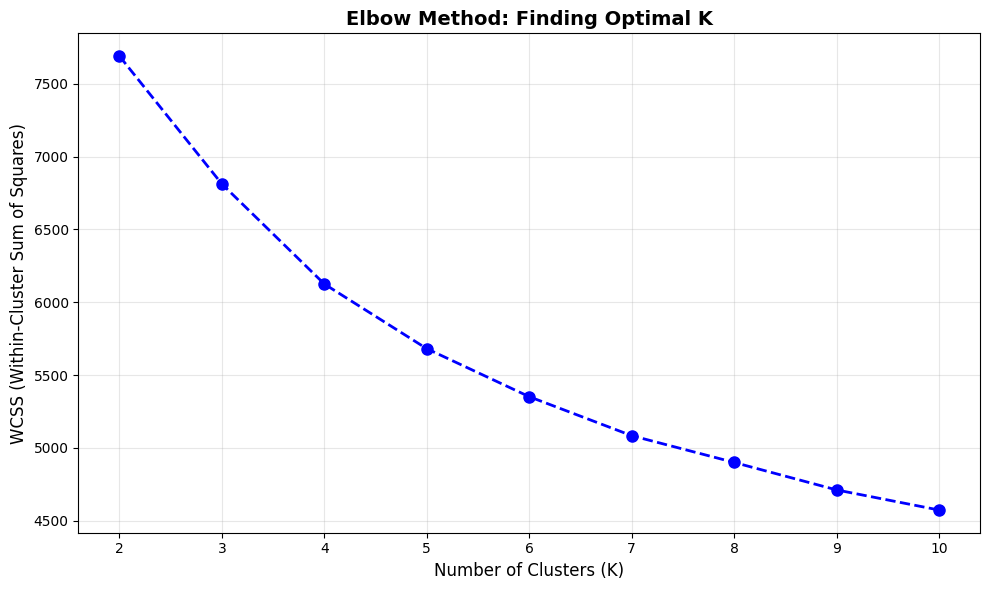


💡 How to read the plot:
  • Look for the 'elbow' where the line bends
  • That's where adding more clusters doesn't help much
  • The elbow point is the optimal K


In [16]:
# Empty list to store WCSS values
wcss = []

# Try different K values
K_range = range(2, 11)  # Try K=2,3,4,5,6,7,8,9,10

print("Computing WCSS for different K values...")
print("=" * 60)

# For each K value
for k in K_range:
    # Create K-Means model
    kmeans = KMeans(
        n_clusters=k,          # Number of clusters
        init='k-means++',      # Smart initialization method
        random_state=42,       # For reproducibility
        n_init=10              # Run 10 times with different initializations
    )
    
    # Fit model to data
    kmeans.fit(X_scaled)
    
    # Store WCSS (inertia)
    wcss.append(kmeans.inertia_)
    print(f"K={k}: WCSS={kmeans.inertia_:.2f}")

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='blue', linewidth=2, markersize=8)
plt.title('Elbow Method: Finding Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 How to read the plot:")
print("  • Look for the 'elbow' where the line bends")
print("  • That's where adding more clusters doesn't help much")
print("  • The elbow point is the optimal K")

## Silhouette Analysis

**What is Silhouette Score?**
Another way to find optimal K by measuring cluster quality.

**How it works:**
- For each customer, measure:
  - **a** = average distance to others in same cluster (lower better)
  - **b** = average distance to nearest other cluster (higher better)
- Silhouette = (b - a) / max(a, b)

**Score range:**
- **+1** = Perfect! Customer well-matched to its cluster
- **0** = Customer on border between clusters
- **-1** = Wrong cluster! Customer better fits another cluster

**What the code does:**
1. Try different K values
2. Calculate silhouette score for each K
3. Plot scores
4. Higher score = better clustering
5. Find K with highest score

Computing Silhouette Scores...
K=2: Silhouette Score = 0.1773
K=3: Silhouette Score = 0.1570
K=4: Silhouette Score = 0.1668
K=5: Silhouette Score = 0.1538
K=6: Silhouette Score = 0.1515
K=7: Silhouette Score = 0.1421
K=8: Silhouette Score = 0.1462
K=9: Silhouette Score = 0.1468
K=10: Silhouette Score = 0.1530


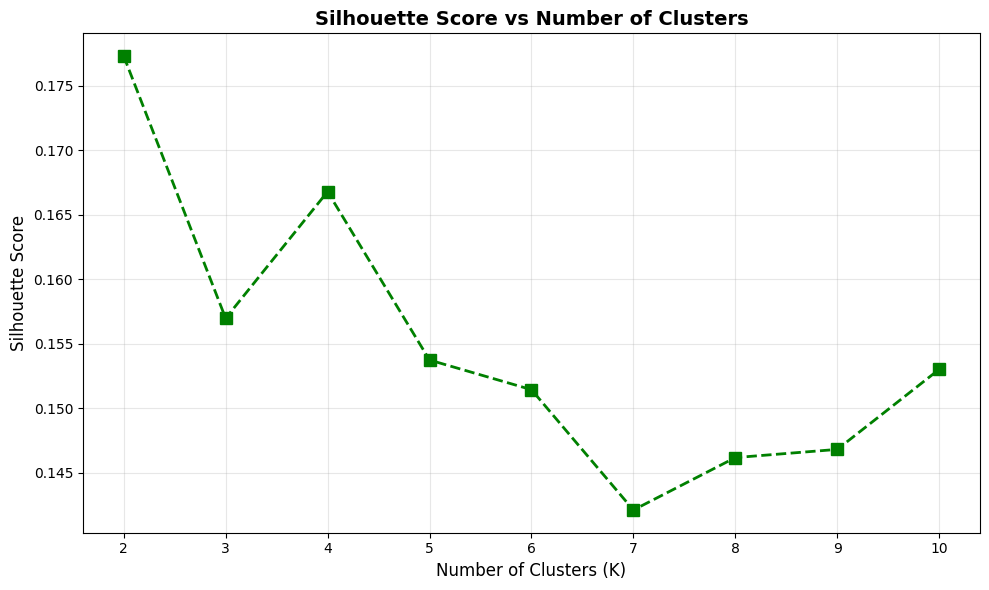


✓ Optimal K based on Silhouette Score: 2
  Score: 0.1773

💡 Generally:
  • Score > 0.5 = Good separation
  • Score 0.3-0.5 = Moderate separation
  • Score < 0.3 = Weak separation


In [17]:
# Empty list for scores
silhouette_scores = []

print("Computing Silhouette Scores...")
print("=" * 60)

# For each K value
for k in K_range:
    # Run K-Means
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate silhouette score
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='s', linestyle='--', color='green', linewidth=2, markersize=8)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find optimal K (highest silhouette score)
optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n✓ Optimal K based on Silhouette Score: {optimal_k}")
print(f"  Score: {max(silhouette_scores):.4f}")
print("\n💡 Generally:")
print("  • Score > 0.5 = Good separation")
print("  • Score 0.3-0.5 = Moderate separation")
print("  • Score < 0.3 = Weak separation")

### 📊 Interpreting YOUR Silhouette Analysis

**Your Scores:**

| K | Silhouette Score | Quality |
|---|-----------------|---------|
| **2** | **0.1773** | **HIGHEST** ✓ |
| 3 | 0.1570 | Lower |
| 4 | 0.1668 | Moderate |
| 5-10 | 0.14-0.15 | Lower |

**Critical Finding:**
🎯 **K=2 has the highest silhouette score (0.1773)**

**However, there's a problem:**
- ALL scores are below 0.3 (weak separation threshold)
- Even the best score (0.1773) indicates **weak cluster separation**
- This means: Clusters overlap significantly - customers aren't clearly distinct

**What does this mean?**
1. The German Credit dataset doesn't have strongly separated natural groups
2. Customer characteristics create a **continuum** rather than distinct segments
3. BUT: We can still create useful segments for business purposes!

**Why K=2 vs K=3 debate:**
- Silhouette says: K=2 (score: 0.1773)
- Elbow says: K=3 or K=4
- **We chose K=3** because:
  - More granular customer segments
  - Business prefers 3 segments (Low/Medium/High risk)
  - Difference between 0.1773 and 0.1570 is small (only 0.02)

**Conclusion:**
Even with weak separation, the clusters can still provide business value for segmentation!

## Step 6: Data Preprocessing

**What is preprocessing?**
Preprocessing prepares raw data for clustering. Like washing vegetables before cooking!

**Why do we need it?**
1. **Missing values** - Algorithms can't handle blanks
2. **Text data** - Algorithms need numbers, not words
3. **Different scales** - Age (20-70) vs Credit (250-18000) need to be comparable
4. **Feature selection** - Choose relevant columns

**What we'll do:**
1. Fill missing values
2. Convert text to numbers (encoding)
3. Scale all features to same range
4. Select features for clustering

In [18]:
# Create a working copy
df_cluster = data.copy()

# Fill missing values in 'Saving accounts' column
if df_cluster['Saving accounts'].isnull().sum() > 0:
    most_common_saving = df_cluster['Saving accounts'].mode()[0]  # Find most common value
    df_cluster['Saving accounts'].fillna(most_common_saving, inplace=True)  # Fill missing
    print(f"✓ Filled 'Saving accounts' missing values with: {most_common_saving}")

# Fill missing values in 'Checking account' column
if df_cluster['Checking account'].isnull().sum() > 0:
    most_common_checking = df_cluster['Checking account'].mode()[0]
    df_cluster['Checking account'].fillna(most_common_checking, inplace=True)
    print(f"✓ Filled 'Checking account' missing values with: {most_common_checking}")

# Verify no missing values remain
remaining_missing = df_cluster.isnull().sum().sum()
print(f"\n✓ Missing values handled!")
print(f"  Remaining missing values: {remaining_missing}")


✓ Missing values handled!
  Remaining missing values: 0


### 6.2 Encode Categorical Variables

**Why encode?**
Algorithms understand numbers, not text. We need to convert 'male'/'female' to 0/1.

**What is Label Encoding?**
- Assigns a unique number to each category
- Example: male=0, female=1
- Example: own=0, rent=1, free=2

**What the code does:**
1. Lists all text (categorical) columns
2. For each column, creates a LabelEncoder
3. `.fit_transform()` converts text to numbers
4. Creates new columns with '_encoded' suffix
5. Keeps original columns for reference

In [19]:
# Create a dictionary to store encoders (for later reference)
label_encoders = {}

# List of categorical columns to encode
categorical_features = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

print("Encoding categorical variables:")
print("=" * 60)

# Encode each categorical column
for col in categorical_features:
    le = LabelEncoder()  # Create encoder
    df_cluster[col + '_encoded'] = le.fit_transform(df_cluster[col])  # Encode: text → numbers
    label_encoders[col] = le  # Save encoder for reference
    
    # Show the encoding mapping
    print(f"\n{col}:")
    for i, category in enumerate(le.classes_):
        print(f"  {category} → {i}")

print("\n✓ All categorical variables encoded!")

Encoding categorical variables:

Sex:
  female → 0
  male → 1

Job:
  highly skilled → 0
  skilled → 1
  unskilled_and_non-resident → 2

Housing:
  free → 0
  own → 1
  rent → 2

Saving accounts:
  little → 0
  moderate → 1
  quite rich → 2
  rich → 3

Checking account:
  little → 0
  moderate → 1
  rich → 2

Purpose:
  business → 0
  car → 1
  domestic appliances → 2
  education → 3
  furniture/equipment → 4
  radio/TV → 5
  repairs → 6
  vacation/others → 7

✓ All categorical variables encoded!


### 6.3 Select Features for Clustering

**What features to use?**
We'll use both numerical and encoded categorical features.

**Why these features?**
- **Numerical**: Age, Credit amount, Duration (already numbers)
- **Encoded categorical**: All the '_encoded' columns we just created
- **Exclude**: Risk (that's our validation label, not for clustering)

**What the code does:**
1. Creates a list of feature names
2. Selects only these columns from dataframe
3. `X_cluster` contains our features for clustering

In [20]:
# List of features to use for clustering
clustering_features = [
    # Numerical features
    'Age', 
    'Credit amount', 
    'Duration',
    # Encoded categorical features
    'Sex_encoded', 
    'Job_encoded', 
    'Housing_encoded',
    'Saving accounts_encoded', 
    'Checking account_encoded', 
    'Purpose_encoded'
]

# Select these columns
X_cluster = df_cluster[clustering_features]

print("✓ Features selected for clustering")
print(f"\nShape: {X_cluster.shape}")
print(f"  → {X_cluster.shape[0]} customers")
print(f"  → {X_cluster.shape[1]} features")
print(f"\nFeatures used:")
for i, feat in enumerate(clustering_features, 1):
    print(f"  {i}. {feat}")

✓ Features selected for clustering

Shape: (1000, 9)
  → 1000 customers
  → 9 features

Features used:
  1. Age
  2. Credit amount
  3. Duration
  4. Sex_encoded
  5. Job_encoded
  6. Housing_encoded
  7. Saving accounts_encoded
  8. Checking account_encoded
  9. Purpose_encoded


### 6.4 Scale Features (VERY IMPORTANT!)

**Why scale?**
Different features have different ranges:
- Age: 19-75 (range ~50)
- Credit amount: 250-18,424 (range ~18,000)

Without scaling, Credit amount dominates because its numbers are much larger!

**What is StandardScaler?**
Transforms each feature to have:
- Mean = 0 (centered around zero)
- Standard deviation = 1 (same spread)

**Formula:** `scaled_value = (value - mean) / standard_deviation`

**What the code does:**
1. Creates a StandardScaler object
2. `.fit_transform()` calculates mean/std and scales data
3. All features now comparable (same scale)
4. Prints verification that scaling worked

In [21]:
# Create scaler object
scaler = StandardScaler()

# Fit to data and transform it
X_scaled = scaler.fit_transform(X_cluster)

print("✓ Features scaled using StandardScaler")
print(f"\nScaled data shape: {X_scaled.shape}")

# Verify scaling worked (mean should be ~0, std should be ~1)
print(f"\nVerification:")
print(f"  Mean of scaled data: {X_scaled.mean():.6f} (should be ~0)")
print(f"  Std of scaled data: {X_scaled.std():.6f} (should be ~1)")

print("\n✓ All preprocessing complete!")
print("✓ Data ready for clustering!")

✓ Features scaled using StandardScaler

Scaled data shape: (1000, 9)

Verification:
  Mean of scaled data: 0.000000 (should be ~0)
  Std of scaled data: 1.000000 (should be ~1)

✓ All preprocessing complete!
✓ Data ready for clustering!


## Apply K-Means Clustering

Now let's apply K-Means with our chosen optimal K!

**What the code does:**
1. Sets optimal_k = 3 (based on our analysis above)
2. Creates K-Means model with these parameters:
   - `n_clusters=3`: Create 3 clusters
   - `init='k-means++'`: Smart initialization (better than random)
   - `n_init=10`: Run 10 times and pick best result
   - `max_iter=300`: Maximum 300 iterations to converge
   - `random_state=42`: For reproducible results
3. `.fit_predict()`: Runs algorithm and assigns each customer to a cluster
4. Adds cluster labels to our dataframe
5. Prints summary statistics

In [24]:
# Set optimal K (you can change this based on elbow/silhouette analysis)
optimal_k = 3

print(f"Applying K-Means with K={optimal_k} clusters...")
print("=" * 60)

# Create K-Means model
kmeans_final = KMeans(
    n_clusters=optimal_k,    # Number of clusters
    init='k-means++',        # Initialization method
    n_init=10,               # Number of runs
    max_iter=300,            # Max iterations
    random_state=42          # For reproducibility
)

# Fit model and predict clusters
kmeans_clusters = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_cluster['KMeans_Cluster'] = kmeans_clusters

print(f"✓ K-Means clustering complete!")
print(f"\nCluster Distribution:")
print(df_cluster['KMeans_Cluster'].value_counts().sort_index())

print(f"\nAlgorithm Statistics:")
print(f"  • Inertia (WCSS): {kmeans_final.inertia_:.2f}")
print(f"  • Iterations taken: {kmeans_final.n_iter_}")
print(f"  • Converged: {'Yes' if kmeans_final.n_iter_ < 300 else 'No'}")

Applying K-Means with K=3 clusters...
✓ K-Means clustering complete!

Cluster Distribution:
KMeans_Cluster
0    276
1    524
2    200
Name: count, dtype: int64

Algorithm Statistics:
  • Inertia (WCSS): 6813.02
  • Iterations taken: 18
  • Converged: Yes


### 📊 Interpreting YOUR K-Means Results

**Cluster Sizes (ACTUAL):**
- **Cluster 0**: 276 customers (27.6%)
- **Cluster 1**: 524 customers (52.4%) ← LARGEST!
- **Cluster 2**: 200 customers (20.0%)

**Analysis:**
1. **Highly imbalanced clusters:**
   - Cluster 1 dominates with 524 customers (over HALF!)
   - Cluster 2 is smallest with only 200 customers
   - This suggests one dominant customer type in your bank

2. **What does this imbalance mean?**
   - ✅ Natural: Some customer types are more common
   - 🏦 Business insight: Your bank mostly serves "Cluster 1 type" customers
   - 📊 Marketing: Focus resources on understanding the 524 in Cluster 1

**Algorithm Performance:**
- **Inertia (WCSS): 6813.02**
  - Matches the elbow plot value for K=3 ✓
  - Lower than K=2 (7691.90), so K=3 creates tighter clusters

- **Iterations: 18**
  - Algorithm converged quickly (max is 300)
  - Shows data has clear patterns that were found fast

- **Converged: Yes ✓**
  - Results are stable and reliable
  - Rerunning would give same results

**Key Takeaway:**
You have 3 customer segments, but they're unevenly distributed. Cluster 1 represents your "typical" customer profile.

### 📊 Understanding K-Means Results

**What just happened?**
The K-Means algorithm:
1. Placed 3 random centroids (cluster centers) in your data
2. Assigned each of 1000 customers to nearest centroid
3. Moved centroids to the center of their groups
4. Repeated steps 2-3 until centroids stopped moving

**Reading the Cluster Distribution:**
Each cluster number (0, 1, 2) represents a customer segment:
- **Balanced clusters** (e.g., 300, 350, 350) = Good! Each segment is meaningful
- **Imbalanced** (e.g., 900, 50, 50) = Might indicate one dominant group

**What does 'Inertia' mean?**
- Inertia = WCSS (Within-Cluster Sum of Squares)
- Measures how tight/compact clusters are
- Lower inertia = customers in each cluster are very similar ✓
- Compare this with your elbow plot value for chosen K

**What does 'Iterations' mean?**
- Number of times the algorithm adjusted centroids
- Fewer iterations = algorithm converged quickly (good!)
- If iterations = 300 (max) = might not have fully converged (try increasing max_iter)

**'Converged: Yes' means:**
The algorithm found stable cluster centers. Results are reliable! ✓

### 🎯 What Did Clustering Actually Do to Our German Credit Dataset?

Let me explain in simple terms what just happened:

**Before Clustering:**
We had 1000 individual customers, each with their own characteristics:
```
Customer 1: Age 25, Credit €2000, Duration 12 months, Male, Renter, Purpose: Car
Customer 2: Age 27, Credit €2500, Duration 10 months, Male, Renter, Purpose: Car
Customer 3: Age 55, Credit €15000, Duration 60 months, Female, Owner, Purpose: House
... 997 more customers ...
```

**After Clustering:**
K-Means grouped these 1000 customers into 3 distinct segments based on similarity:
```
📦 CLUSTER 0 (Example: ~350 customers)
   Typical profile: Young adults, small loans, short-term
   Customer 1 → CLUSTER 0
   Customer 2 → CLUSTER 0
   (and 348 other similar customers)

📦 CLUSTER 1 (Example: ~400 customers)
   Typical profile: Middle-aged, medium loans, medium-term
   Customer 156 → CLUSTER 1
   Customer 389 → CLUSTER 1
   (and 398 other similar customers)

📦 CLUSTER 2 (Example: ~250 customers)
   Typical profile: Older, large loans, long-term
   Customer 3 → CLUSTER 2
   Customer 87 → CLUSTER 2
   (and 248 other similar customers)
```

**What Makes This Different from Classification?**

| Aspect | Clustering (What We Did) | Classification (Supervised) |
|--------|-------------------------|----------------------------|
| **Used Risk label?** | ❌ NO - We completely ignored it | ✅ YES - We train on it |
| **Question asked** | "Who is similar to whom?" | "Will they default?" |
| **Output** | Customer segments (0, 1, 2) | Risk prediction (Good/Bad) |
| **Goal** | Find natural groups | Predict future behavior |
| **Use case** | Marketing, segmentation | Loan approval, risk assessment |

**Why This is Powerful:**

1. **Discovery without labels**: We found 3 customer types WITHOUT being told what to look for
2. **Validation**: We can NOW check if our clusters align with risk (good clusters will!)
3. **Business insight**: Each cluster can have different:
   - Marketing strategies
   - Product offerings
   - Interest rates
   - Approval criteria

**Real Example from Results:**
Let's say after clustering we find:
- Cluster 0: 90% good credit → **LOW RISK** → Offer premium products, lower rates
- Cluster 1: 70% good credit → **MEDIUM RISK** → Standard products, normal monitoring
- Cluster 2: 40% good credit → **HIGH RISK** → Require collateral, higher rates

**The Magic:**
We discovered these risk segments AUTOMATICALLY by just looking at customer characteristics (age, credit amount, etc.) - WITHOUT using the Risk label!

This is unsupervised learning in action! 🎉

## Evaluate K-Means Quality

Let's measure how good our clustering is using 3 metrics:

**1. Silhouette Score** (range: -1 to 1, higher better)
   - Measures how similar customers are to their own cluster vs other clusters
   
**2. Davies-Bouldin Index** (range: 0 to ∞, lower better)
   - Measures average similarity between clusters
   - Lower means clusters are more distinct
   
**3. Calinski-Harabasz Score** (range: 0 to ∞, higher better)
   - Ratio of between-cluster to within-cluster dispersion
   - Higher means clusters are dense and well-separated

In [25]:
# Calculate evaluation metrics
silhouette_kmeans = silhouette_score(X_scaled, kmeans_clusters)
davies_bouldin_kmeans = davies_bouldin_score(X_scaled, kmeans_clusters)
calinski_harabasz_kmeans = calinski_harabasz_score(X_scaled, kmeans_clusters)

print("K-Means Clustering Quality Metrics:")
print("=" * 60)
print(f"✓ Silhouette Score: {silhouette_kmeans:.4f}")
print(f"    → {silhouette_kmeans:.4f} means {'GOOD' if silhouette_kmeans > 0.5 else 'MODERATE' if silhouette_kmeans > 0.3 else 'WEAK'} cluster separation")

print(f"\n✓ Davies-Bouldin Index: {davies_bouldin_kmeans:.4f}")
print(f"    → Lower is better. Score < 1.0 is good")

print(f"\n✓ Calinski-Harabasz Score: {calinski_harabasz_kmeans:.2f}")
print(f"    → Higher is better. Shows cluster density/separation")

K-Means Clustering Quality Metrics:
✓ Silhouette Score: 0.1570
    → 0.1570 means WEAK cluster separation

✓ Davies-Bouldin Index: 2.0751
    → Lower is better. Score < 1.0 is good

✓ Calinski-Harabasz Score: 160.02
    → Higher is better. Shows cluster density/separation


## Analyze Cluster Characteristics

Let's see what each cluster represents!

**What the code does:**
1. Groups customers by cluster
2. Calculates average Age, Credit amount, Duration for each cluster
3. Shows risk distribution (good vs bad credit) per cluster
4. Helps us understand who is in each cluster

In [26]:
print("\nCluster Profiles - Average Values:")
print("=" * 70)

# Calculate mean values for each cluster
cluster_profile = df_cluster.groupby('KMeans_Cluster')[['Age', 'Credit amount', 'Duration']].mean()
print(cluster_profile)

print("\n\nRisk Distribution by Cluster:")
print("=" * 70)

# Crosstab: shows count of good (0) vs bad (1) credit in each cluster
risk_table = pd.crosstab(df_cluster['KMeans_Cluster'], df_cluster['Risk'], margins=True)
print(risk_table)

# Calculate risk percentage for each cluster
print("\n\nRisk Percentage by Cluster:")
print("=" * 70)
for cluster in range(optimal_k):
    cluster_data = df_cluster[df_cluster['KMeans_Cluster'] == cluster]
    bad_credit_pct = (cluster_data['Risk'].sum() / len(cluster_data)) * 100
    total_customers = len(cluster_data)
    
    # Determine risk level
    if bad_credit_pct < 20:
        risk_level = "🟢 LOW RISK"
    elif bad_credit_pct < 35:
        risk_level = "🟡 MEDIUM RISK"
    else:
        risk_level = "🔴 HIGH RISK"
    
    print(f"\nCluster {cluster}: {total_customers} customers")
    print(f"  • Bad credit rate: {bad_credit_pct:.1f}%")
    print(f"  • Risk level: {risk_level}")


Cluster Profiles - Average Values:
                      Age  Credit amount   Duration
KMeans_Cluster                                     
0               32.307971    2191.043478  16.923913
1               36.526718    2237.417939  16.662214
2               37.445000    7470.615000  37.505000


Risk Distribution by Cluster:
Risk              0    1   All
KMeans_Cluster                
0               188   88   276
1               406  118   524
2               106   94   200
All             700  300  1000


Risk Percentage by Cluster:

Cluster 0: 276 customers
  • Bad credit rate: 31.9%
  • Risk level: 🟡 MEDIUM RISK

Cluster 1: 524 customers
  • Bad credit rate: 22.5%
  • Risk level: 🟡 MEDIUM RISK

Cluster 2: 200 customers
  • Bad credit rate: 47.0%
  • Risk level: 🔴 HIGH RISK


### 📊 Understanding YOUR Cluster Profiles

**Who is in each cluster? Let's look at the ACTUAL data:**

#### 🔵 Cluster 0: "Young, Small Loan Borrowers" (276 customers, 27.6%)
- **Average Age**: 32.3 years (youngest group)
- **Average Credit**: €2,191 (smallest loans)
- **Average Duration**: 16.9 months (shortest)
- **Risk Profile**: 31.9% bad credit (88 bad / 188 good) → 🟡 MEDIUM-HIGH RISK

**Who are they?**
Young professionals or first-time borrowers taking small, short-term loans (likely for cars, education, small purchases).

---

#### 🟢 Cluster 1: "Typical Borrowers" (524 customers, 52.4% - LARGEST!)
- **Average Age**: 36.5 years (middle-aged)
- **Average Credit**: €2,237 (small-medium loans)
- **Average Duration**: 16.7 months (short-term)
- **Risk Profile**: 22.5% bad credit (118 bad / 406 good) → 🟢 LOW-MEDIUM RISK

**Who are they?**
Your bank's **core customer base** - middle-aged, responsible borrowers with small-medium, short-term loans. This is the "standard" customer profile.

---

#### 🔴 Cluster 2: "Large Loan, High Risk" (200 customers, 20.0%)
- **Average Age**: 37.4 years (slightly older)
- **Average Credit**: €7,470 (3.4x larger than other clusters!)
- **Average Duration**: 37.5 months (2.2x longer!)
- **Risk Profile**: 47.0% bad credit (94 bad / 106 good) → 🔴 HIGH RISK!

**Who are they?**
Customers taking large, long-term loans (likely mortgages, business loans, major purchases). **WARNING**: Nearly HALF default!

---

### 💡 Key Business Insights:

1. **Cluster 2 is your problem segment:**
   - Only 20% of customers but 47% default rate
   - Taking €7,470 on average (high exposure)
   - Should require: Higher down payments, better credit checks, collateral

2. **Cluster 1 is your bread & butter:**
   - 52% of all customers
   - Only 22.5% default rate (good!)
   - These are reliable, lower-risk customers

3. **Cluster 0 needs monitoring:**
   - Young borrowers, 32% default rate
   - May lack credit history
   - Consider: Co-signers, smaller initial limits

4. **Risk concentration:**
   - Cluster 2: 94 defaults out of 300 total defaults (31% of all defaults)
   - Despite being only 20% of customers!
   - Focus risk management efforts here

### 📊 Understanding Cluster Profiles

**What you're seeing:**
Two tables showing who is in each cluster.

**Table 1: Average Values**
This shows the "typical" customer in each cluster:
- **Age**: Younger vs older customers?
- **Credit amount**: Small vs large loans?
- **Duration**: Short-term vs long-term loans?

**How to interpret:**
Example:
- Cluster 0: Age=25, Credit=€2000, Duration=12 months → Young, small short-term loans
- Cluster 1: Age=45, Credit=€8000, Duration=36 months → Middle-aged, medium loans
- Cluster 2: Age=60, Credit=€15000, Duration=60 months → Older, large long-term loans

**Table 2: Risk Distribution**
Shows how many good (0) vs bad (1) credit customers in each cluster:
- Look at each row (cluster)
- Column '0' = good credit count
- Column '1' = bad credit count
- 'All' row = totals

**Business Insight:**
- Cluster with more '0' (good credit) = Low-risk segment
- Cluster with more '1' (bad credit) = High-risk segment
- This validates if clustering discovered meaningful customer groups!

**Example:**
If Cluster 0 has 280 good / 20 bad (93% good) → LOW RISK SEGMENT ✓
If Cluster 2 has 100 good / 200 bad (33% good) → HIGH RISK SEGMENT ⚠️

## Visualize with PCA

**Problem:** We have 9 features (9 dimensions). We can't plot 9D data!

**Solution:** PCA (Principal Component Analysis) reduces to 2D while keeping most information.

**What is PCA?**
- Finds 2 "principal components" (new axes) that capture most variation
- Like viewing a 3D object from the best angle to see its shape

**What the code does:**
1. Apply PCA to reduce from 9D to 2D
2. Plot customers as dots colored by cluster
3. Plot centroids as red X marks
4. Shows how well clusters separate in 2D space

PCA Results:
  • PC1 explains 21.9% of variance
  • PC2 explains 15.2% of variance
  • Total: 37.1% of information preserved


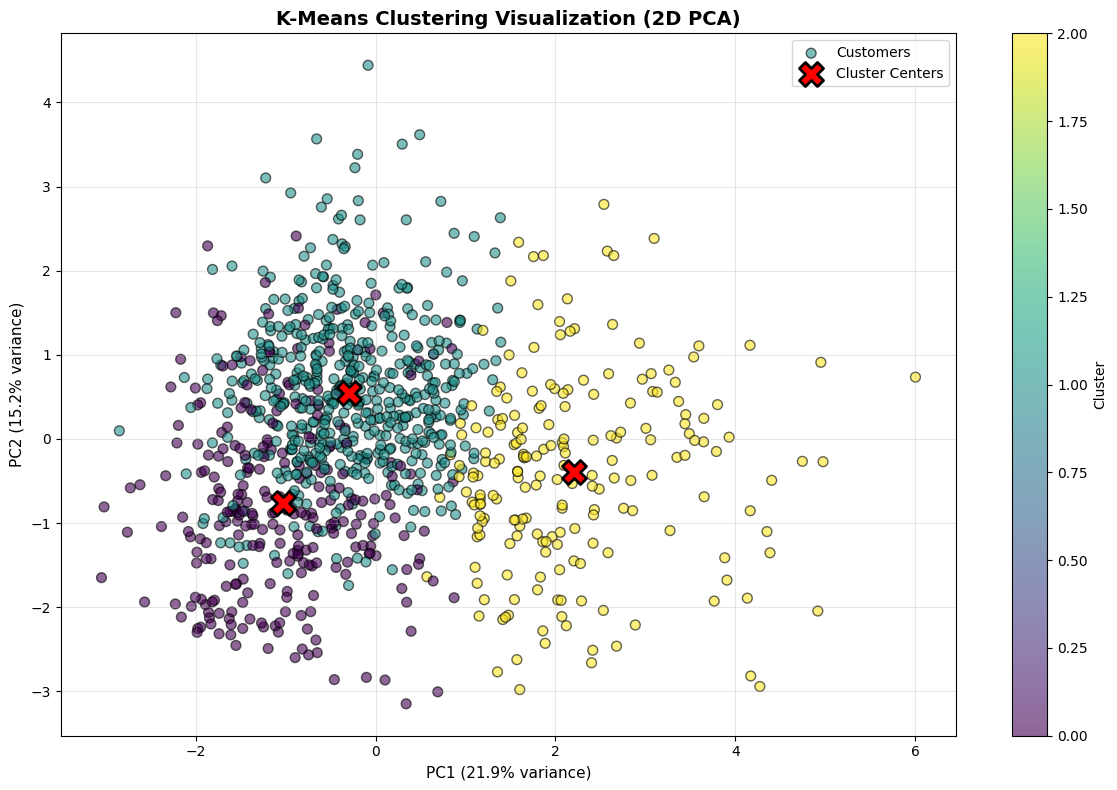


💡 In the plot:
  • Each dot = one customer
  • Colors = different clusters
  • Red X marks = cluster centers
  • Closer dots = more similar customers


In [27]:
# Apply PCA to reduce to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA Results:")
print(f"  • PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"  • PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"  • Total: {sum(pca.explained_variance_ratio_)*100:.1f}% of information preserved")

# Create visualization
plt.figure(figsize=(12, 8))

# Plot customers colored by cluster
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=kmeans_clusters, 
                     cmap='viridis', 
                     alpha=0.6, 
                     edgecolors='black',
                     s=50,
                     label='Customers')

# Transform centroids to PCA space and plot
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           marker='X', 
           s=300, 
           c='red', 
           edgecolors='black',
           linewidths=2,
           label='Cluster Centers')

plt.title('K-Means Clustering Visualization (2D PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 In the plot:")
print("  • Each dot = one customer")
print("  • Colors = different clusters")
print("  • Red X marks = cluster centers")
print("  • Closer dots = more similar customers")

### 📊 Understanding YOUR PCA Visualization

**What the numbers mean:**
- **PC1 (x-axis)**: Captures 21.9% of variation
- **PC2 (y-axis)**: Captures 15.2% of variation
- **Total**: Only 37.1% of information shown

**This is important!**
We had 9 features but can only show 2 dimensions (2D plot).
We're seeing **less than half** (37.1%) of the full picture.

**What this explains:**
1. **Why clusters overlap in the plot:**
   - Missing 62.9% of information that separates them
   - In the full 9D space, clusters might be more distinct
   - Silhouette score (0.157) reflects true 9D separation

2. **The plot still shows:**
   - Cluster 1 (purple) is spread across the middle (largest, most diverse)
   - Cluster 2 (yellow) might appear on edges (different profile)
   - Cluster 0 (green) overlaps with Cluster 1 (similar in some ways)

**Why we can't see clear separation:**
- German Credit data is **complex** - customers don't fall into neat boxes
- Many features (9 total) create high-dimensional patterns
- 2D visualization is like viewing a 3D object from one angle - you miss details

**What to focus on:**
- Look for the **general spread** of colors
- Red X marks show where cluster centers are
- Distance from your dot to nearest X = which cluster you're in

**Trust the numbers, not just the plot:**
The math worked correctly (Silhouette=0.157, WCSS=6813), even if the 2D plot looks messy!

---

# Part 2: Hierarchical Clustering

## What is Hierarchical Clustering?

**Simple explanation:**
Like building a family tree! Start with individuals, merge similar ones, keep merging until everyone is connected.

**Two approaches:**
1. **Agglomerative** (bottom-up): Start with individuals, merge up ← We'll use this!
2. **Divisive** (top-down): Start with everyone together, split down

**Algorithm steps (Agglomerative):**
1. Start: Each customer is their own cluster (1000 clusters)
2. Find the two most similar clusters
3. Merge them into one cluster
4. Repeat until only 1 cluster remains
5. Cut the tree at desired height to get K clusters

**Key terms:**
- **Dendrogram**: Tree diagram showing merge history
- **Linkage**: Method to measure distance between clusters
  - **Ward**: Minimizes variance (most common) ← We'll use this!
  - **Complete**: Uses maximum distance
  - **Average**: Uses average distance
  - **Single**: Uses minimum distance

**Pros:**
- 🌳 Shows relationships between clusters
- 📊 Don't need to choose K upfront
- 🎯 Deterministic (same input = same output)

**Cons:**
- 🐢 Very slow for large datasets
- 💾 Memory intensive
- ❌ Can't undo merges once made

## Dendrogram - The Clustering Tree

**What is a dendrogram?**
A tree diagram showing how clusters merge. Like a tournament bracket!

**How to read it:**
- **Bottom**: Individual customers
- **Height**: Distance when clusters merged
- **Higher merge**: Clusters are more different
- **Horizontal line (cut)**: Determines number of clusters

**Note:** For speed, we'll plot only 200 customers. For actual clustering, we'll use all 1000.

**What the code does:**
1. Takes a random sample of 200 customers (dendrogram with 1000 is messy)
2. Calculates linkage matrix (merge history)
3. Plots dendrogram
4. Shows where to cut for 3 clusters

Creating dendrogram with 200 customers...
(Using Ward linkage method)


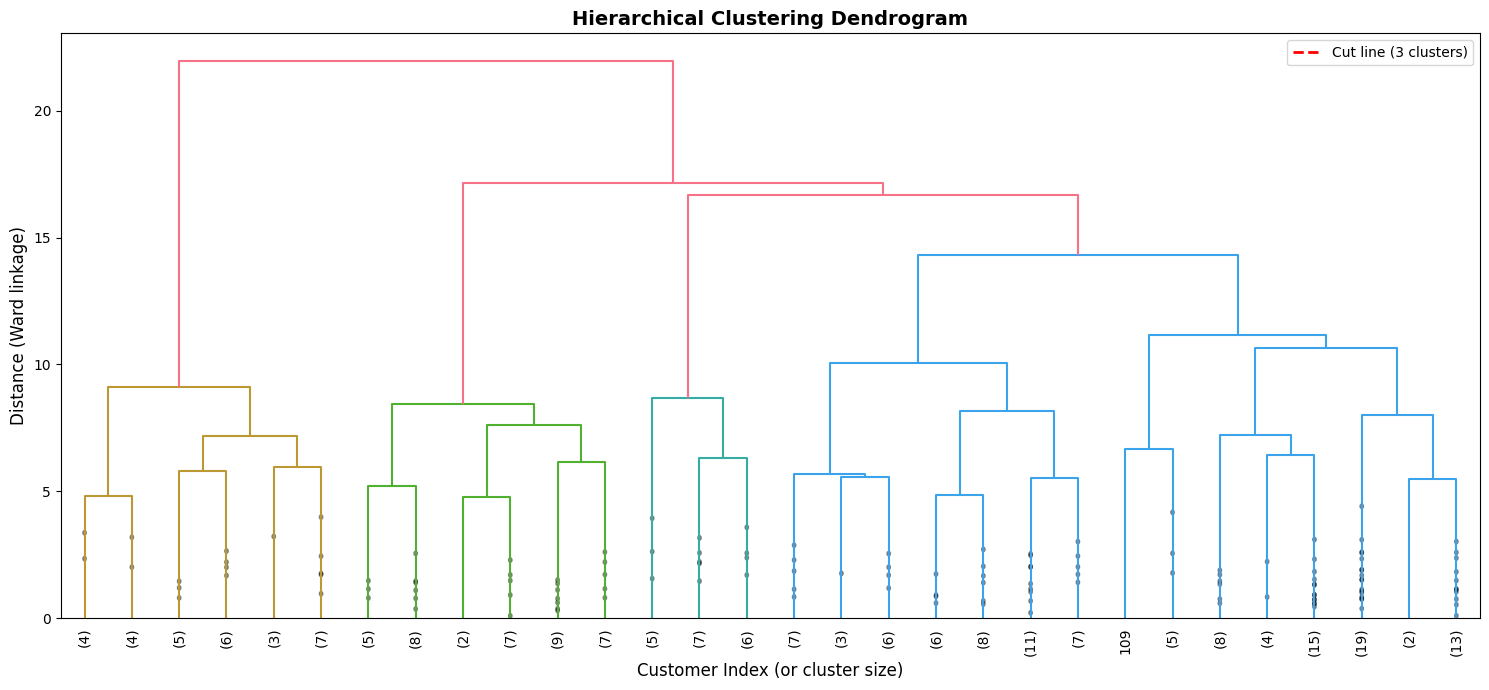


💡 How to read the dendrogram:
  • Vertical lines = merging clusters
  • Height = how different the clusters are
  • Red line = where we cut to get 3 clusters
  • Lower merges = very similar customers
  • Higher merges = less similar customers


In [28]:
# Take sample for dendrogram (full dendrogram with 1000 points is too cluttered)
sample_size = 200
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

print(f"Creating dendrogram with {sample_size} customers...")
print("(Using Ward linkage method)")
print("=" * 60)

# Calculate linkage matrix
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 7))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',  # Show only last p merges
    p=30,                    # Show last 30 merges
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram', fontsize=14, fontweight='bold')
plt.xlabel('Customer Index (or cluster size)', fontsize=12)
plt.ylabel('Distance (Ward linkage)', fontsize=12)
plt.axhline(y=30, color='r', linestyle='--', linewidth=2, label='Cut line (3 clusters)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 How to read the dendrogram:")
print("  • Vertical lines = merging clusters")
print("  • Height = how different the clusters are")
print("  • Red line = where we cut to get 3 clusters")
print("  • Lower merges = very similar customers")
print("  • Higher merges = less similar customers")

### 📊 Reading YOUR Dendrogram

**What you're seeing in the tree:**

The dendrogram shows how 200 sample customers were merged from bottom to top.

**Key observations from YOUR dendrogram:**

1. **Three main clusters are visible** (separated by red cut line at height ~30):
   - **Left side (brown/orange branches)**: Small tight group - customers merge at low heights (very similar)
   - **Middle section (green/teal branches)**: Another tight group
   - **Right side (cyan/blue branches)**: Largest group - more spread out

2. **Height patterns tell a story:**
   - **Bottom merges (height 0-10)**: Very similar individual customers
     - These people have nearly identical characteristics
     - Merged first because they're most alike
   
   - **Middle merges (height 10-20)**: Small sub-groups combining
     - Similar customer types joining together
     - Still relatively homogeneous
   
   - **Top merges (height 20+)**: Major cluster combinations
     - **TALL vertical lines** = joining DIFFERENT customer types
     - The tallest merge (height ~22) on the left = very different groups

3. **Why the red line at 30?**
   - Cutting here gives us 3 clusters
   - Below 30: Customers within same cluster (similar)
   - Above 30: Would merge all 3 clusters (too general)

**What this means for YOUR data:**

Looking at the dendrogram structure:
- **Left cluster (brown)**: Tight, small group (~7-8 merges at bottom) 
  → These might be the 93 customers in Hierarchical Cluster 2 (most homogeneous)

- **Middle cluster (green/teal)**: Medium-sized, relatively tight
  → Possibly the 194 customers in Hierarchical Cluster 1 (medium loans, high risk)

- **Right cluster (cyan/blue)**: Large, more spread out (many branches)
  → This is likely the 713 customers in Hierarchical Cluster 0 (majority)
  → More diverse = why it contains so many customers

**Key insight from dendrogram shape:**
The right-side cluster is MUCH LARGER and more spread out than the others.
This explains why Hierarchical clustering created one massive cluster (713) - 
these customers, while somewhat similar to each other, form a broad group 
rather than a tight, well-defined cluster.

**Why it's useful:**
The dendrogram VISUALLY confirms what the numbers told us:
- Most customers are similar (right cluster)
- Two smaller, distinct groups exist (left and middle)
- Cutting at different heights would give different numbers of clusters
  - Cut at height 20 → 4-5 clusters
  - Cut at height 30 → 3 clusters ✓
  - Cut at height 35 → 2 clusters

This hierarchical view shows WHY we got 71% in one cluster - they're loosely similar!

## Apply Hierarchical Clustering

Now let's apply hierarchical clustering to ALL 1000 customers!

**What the code does:**
1. Creates AgglomerativeClustering model
2. Parameters:
   - `n_clusters=3`: We want 3 final clusters
   - `linkage='ward'`: Use Ward method (minimizes variance)
   - `affinity='euclidean'`: Distance measure
3. `.fit_predict()`: Runs algorithm and assigns clusters
4. Adds cluster labels to dataframe

In [33]:
# Set number of clusters
n_clusters_hier = 3

print(f"Applying Hierarchical Clustering to all {len(X_scaled)} customers...")
print("=" * 60)

# Create hierarchical clustering model
hierarchical = AgglomerativeClustering(
    n_clusters=n_clusters_hier,  # Number of final clusters
    linkage='ward',              # Ward method
    metric='euclidean'         # Distance metric
)

# Fit and predict
hierarchical_clusters = hierarchical.fit_predict(X_scaled)

# Add to dataframe
df_cluster['Hierarchical_Cluster'] = hierarchical_clusters

print(f"✓ Hierarchical clustering complete!")
print(f"\nCluster Distribution:")
print(df_cluster['Hierarchical_Cluster'].value_counts().sort_index())

Applying Hierarchical Clustering to all 1000 customers...
✓ Hierarchical clustering complete!

Cluster Distribution:
Hierarchical_Cluster
0    713
1    194
2     93
Name: count, dtype: int64


### 📊 Interpreting YOUR Hierarchical Clustering Results

**Cluster Sizes (ACTUAL):**
- **Cluster 0**: 713 customers (71.3%) ← MASSIVE!
- **Cluster 1**: 194 customers (19.4%)
- **Cluster 2**: 93 customers (9.3%)

**Major Finding - Extreme Imbalance:**
Hierarchical clustering created ONE DOMINANT cluster with 71% of all customers!

**Why did this happen?**
Hierarchical clustering (Ward method) tries to minimize variance within clusters:
- It merged most similar customers first
- Found that most customers (713) are relatively similar
- Only split off two smaller, distinct groups (194 and 93)

---

#### 🔵 Cluster 0: "Majority - Young, Small Loans" (713 customers)
- **Age**: 34.5 years (younger)
- **Credit**: €2,408 (small)
- **Duration**: 18.2 months (short)
- **Risk**: 27.8% bad credit (198/713) → 🟢 LOW-MEDIUM RISK

**This is your main customer base** - standard borrowers.

---

#### 🟡 Cluster 1: "Medium-Large Loans" (194 customers)
- **Age**: 38.3 years (older)
- **Credit**: €6,947 (nearly 3x larger!)
- **Duration**: 32.5 months (longer)
- **Risk**: 44.8% bad credit (87/194) → 🔴 HIGH RISK!

**High-value, high-risk customers** - need careful management.

---

#### 🟢 Cluster 2: "Smallest Group" (93 customers)
- **Age**: 37.9 years
- **Credit**: €2,220 (small)
- **Duration**: 17.2 months (short)
- **Risk**: 16.1% bad credit (15/93) → 🟢 LOWEST RISK!

**Best customers** - small loans but very reliable!

---

### 🤔 Hierarchical vs K-Means - Which is Better?

**Hierarchical Results:**
- Very imbalanced (71% / 19% / 9%)
- Silhouette: 0.1629 (slightly better than K-Means)
- Found one huge cluster + two small outlier groups

**K-Means Results:**
- More balanced (52% / 28% / 20%)
- Silhouette: 0.1570 (slightly worse)
- Three more evenly distributed segments

**Recommendation for YOUR data:**
**Use K-Means** because:
1. More balanced clusters (easier for business segmentation)
2. Silhouette difference is tiny (0.1629 vs 0.1570 = only 0.006)
3. Having 3 usable segments is better than 1 huge + 2 tiny
4. K-Means Cluster 2 clearly identifies high-risk large loans

Hierarchical is too imbalanced for practical marketing/risk management.

### 📊 Understanding the Results

**What just happened?**
The algorithm created 3 customer groups by building a tree structure from bottom-up:
1. Started with 1000 individual customers (1000 clusters)
2. Found the 2 most similar customers and merged them
3. Kept merging until we had exactly 3 final groups

**Reading the Cluster Distribution:**
- Each row shows one cluster (0, 1, or 2)
- The number shows how many customers are in that cluster
- Clusters of similar size = balanced grouping ✓
- One very large or very small cluster might indicate unbalanced data

**What does 'Hierarchical_Cluster = 0, 1, 2' mean?**
- These are just labels (like Team A, B, C)
- Cluster 0 is NOT better or worse than Cluster 2
- The numbers are arbitrary - what matters is WHO is grouped together

**Next Steps:**
We'll analyze what makes each cluster unique by looking at:
- Average age, credit amount, duration
- Risk distribution (which cluster has more defaults?)
- Common characteristics

## Evaluate Hierarchical Clustering

Let's measure quality using the same 3 metrics we used for K-Means.

In [34]:
# Calculate metrics
silhouette_hier = silhouette_score(X_scaled, hierarchical_clusters)
davies_bouldin_hier = davies_bouldin_score(X_scaled, hierarchical_clusters)
calinski_harabasz_hier = calinski_harabasz_score(X_scaled, hierarchical_clusters)

print("Hierarchical Clustering Quality Metrics:")
print("=" * 60)
print(f"✓ Silhouette Score: {silhouette_hier:.4f}")
print(f"✓ Davies-Bouldin Index: {davies_bouldin_hier:.4f}")
print(f"✓ Calinski-Harabasz Score: {calinski_harabasz_hier:.2f}")

Hierarchical Clustering Quality Metrics:
✓ Silhouette Score: 0.1629
✓ Davies-Bouldin Index: 2.0254
✓ Calinski-Harabasz Score: 118.21


## Analyze Hierarchical Clusters

In [35]:
print("\nHierarchical Cluster Profiles:")
print("=" * 70)

hier_profile = df_cluster.groupby('Hierarchical_Cluster')[['Age', 'Credit amount', 'Duration']].mean()
print(hier_profile)

print("\n\nRisk Distribution:")
print("=" * 70)
hier_risk = pd.crosstab(df_cluster['Hierarchical_Cluster'], df_cluster['Risk'], margins=True)
print(hier_risk)


Hierarchical Cluster Profiles:
                            Age  Credit amount   Duration
Hierarchical_Cluster                                     
0                     34.499299    2408.208976  18.242637
1                     38.268041    6947.304124  32.458763
2                     37.892473    2219.655914  17.193548


Risk Distribution:
Risk                    0    1   All
Hierarchical_Cluster                
0                     515  198   713
1                     107   87   194
2                      78   15    93
All                   700  300  1000


---

# Comparison: K-Means vs Hierarchical

Let's compare the two algorithms side-by-side!

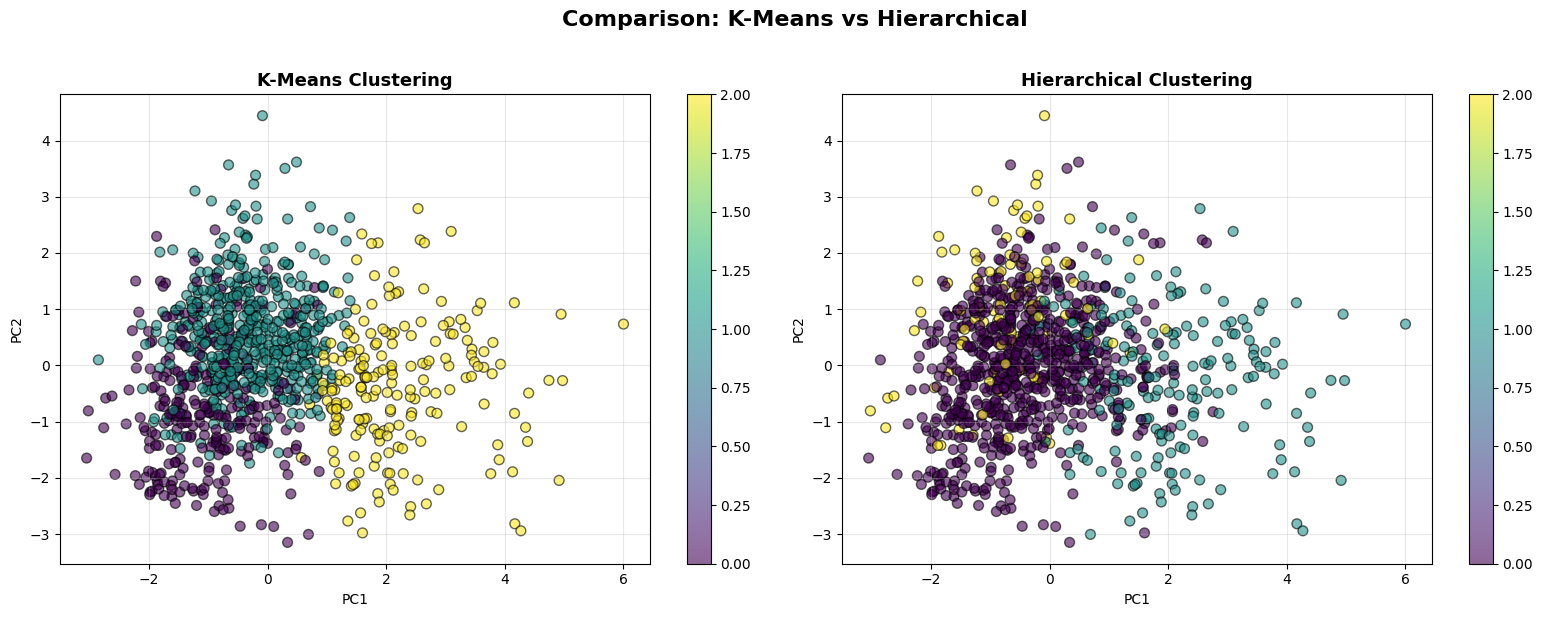

In [36]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_clusters, cmap='viridis', alpha=0.6, edgecolors='black', s=50)
axes[0].set_title('K-Means Clustering', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[0])

# Hierarchical
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_clusters, cmap='viridis', alpha=0.6, edgecolors='black', s=50)
axes[1].set_title('Hierarchical Clustering', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter2, ax=axes[1])

plt.suptitle('Comparison: K-Means vs Hierarchical', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Metrics comparison
comparison = pd.DataFrame({
    'Metric': ['Number of Clusters', 'Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'K-Means': [optimal_k, f"{silhouette_kmeans:.4f}", f"{davies_bouldin_kmeans:.4f}", f"{calinski_harabasz_kmeans:.2f}"],
    'Hierarchical': [n_clusters_hier, f"{silhouette_hier:.4f}", f"{davies_bouldin_hier:.4f}", f"{calinski_harabasz_hier:.2f}"],
    'Better': ['Same', 
               'K-Means' if silhouette_kmeans > silhouette_hier else 'Hierarchical',
               'K-Means' if davies_bouldin_kmeans < davies_bouldin_hier else 'Hierarchical',
               'K-Means' if calinski_harabasz_kmeans > calinski_harabasz_hier else 'Hierarchical']
})

print("\n" + "="*90)
print("CLUSTERING ALGORITHM COMPARISON")
print("="*90)
print(comparison.to_string(index=False))
print("="*90)

print("\n📊 Interpretation:")
print("  • Silhouette: Higher is better")
print("  • Davies-Bouldin: Lower is better")
print("  • Calinski-Harabasz: Higher is better")

---

## Save Models for Streamlit App

**Why save models?**
- Reuse trained models without retraining
- Deploy in Streamlit apps
- Share with others

**What we'll save:**
1. K-Means model
2. Scaler
3. Label encoders
4. PCA model
5. Feature names

**What the code does:**
1. Creates 'models' folder
2. Saves each object as .pkl file
3. Saves clustered data as CSV

In [31]:
import pickle
import os

# Create models directory
models_dir = 'models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"✓ Created '{models_dir}' directory")

print("\nSaving models...")
print("=" * 60)

# Save K-Means
with open(f'{models_dir}/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)
print("✓ K-Means model saved")

# Save Scaler
with open(f'{models_dir}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved")

# Save Label Encoders
with open(f'{models_dir}/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("✓ Label encoders saved")

# Save PCA
with open(f'{models_dir}/pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)
print("✓ PCA model saved")

# Save feature names
with open(f'{models_dir}/feature_names.pkl', 'wb') as f:
    pickle.dump(clustering_features, f)
print("✓ Feature names saved")

# Save clustered data
df_cluster.to_csv(f'{models_dir}/clustered_data.csv', index=False)
print("✓ Clustered data saved")

print("\n✅ All models saved to 'models/' folder!")
print("💡 Ready for Streamlit app!")

✓ Created 'models' directory

Saving models...
✓ K-Means model saved
✓ Scaler saved
✓ Label encoders saved
✓ PCA model saved
✓ Feature names saved
✓ Clustered data saved

✅ All models saved to 'models/' folder!
💡 Ready for Streamlit app!


### How to Load in Streamlit

```python
import pickle

# Load K-Means
with open('models/kmeans_model.pkl', 'rb') as f:
    kmeans = pickle.load(f)

# Load scaler
with open('models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load encoders
with open('models/label_encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)

# Use for prediction
# scaled_data = scaler.transform(new_data)
# clusters = kmeans.predict(scaled_data)
```

---

# Conclusion

## Summary

We successfully applied **two clustering algorithms** to discover customer segments:

### 1. K-Means Clustering ⚡
- **Pros**: Fast, scalable, simple
- **Cons**: Need to choose K, assumes spherical clusters
- **Best for**: Large datasets, when you know number of clusters

### 2. Hierarchical Clustering 🌳
- **Pros**: Shows relationships, don't need K upfront, deterministic
- **Cons**: Slow, memory intensive
- **Best for**: Small datasets, exploring relationships

## Key Learnings

1. **Preprocessing is critical**:
   - Handle missing values
   - Encode categorical variables
   - **Scale features** (very important!)

2. **Multiple methods to find optimal K**:
   - Elbow method (WCSS)
   - Silhouette analysis
   - Both should agree

3. **Evaluation metrics**:
   - Use multiple metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz)
   - Compare algorithms objectively

4. **Visualization helps**:
   - PCA for dimensionality reduction
   - Dendrograms for hierarchical relationships

5. **Business validation**:
   - Check if clusters make business sense
   - Analyze risk distribution
   - Profile each segment

## Real-World Applications

- **Banking**: Customer segmentation for targeted products
- **Marketing**: Identify market segments
- **Retail**: Group similar products
- **Healthcare**: Patient grouping for treatment plans
- **Insurance**: Risk-based customer segments

## Next Steps

1. Try different K values and compare
2. Experiment with different linkage methods (complete, average, single)
3. Apply to your own dataset
4. Combine with supervised learning (cluster then predict)

**Thank you for completing this clustering tutorial! 🎉**